## 1. Configuración e imports

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

BASE_DIR = Path().resolve().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
BACKEND_DIR = BASE_DIR / 'backend'

## 2. Carga y preprocesamiento

In [2]:
X = pd.read_csv(PROCESSED_DIR / 'X_clean.csv')
y = pd.read_csv(PROCESSED_DIR / 'y_clean.csv')['genre']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
genres = le.classes_.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

X_train shape: (6397, 355)
X_test shape: (1600, 355)


## 3. Entrenamiento de 3 modelos

In [3]:
models = {
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=4, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, eval_metric='mlogloss'
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Entrenando {name}...")
    try:
        model.fit(X_train_scaled, y_train)
        trained_models[name] = model
        print(f"✅ {name} entrenado exitosamente.")
    except Exception as e:
        print(f"❌ Error entrenando {name}: {e}")

Entrenando SVM...
✅ SVM entrenado exitosamente.
Entrenando RandomForest...
✅ RandomForest entrenado exitosamente.
Entrenando XGBoost...
✅ XGBoost entrenado exitosamente.


## 4. Evaluación comparativa

,Train Acc,Test Acc,F1 Macro,Overfitting Gap
Model,,,,
SVM,0.954510,0.576875,0.572934,0.377635
RandomForest,0.959356,0.515625,0.506408,0.443731
XGBoost,0.926059,0.566250,0.562992,0.359809



🏆 Mejor modelo: SVM

Classification Report:
               precision    recall  f1-score   support

   Electronic       0.55      0.60      0.57       200
 Experimental       0.48      0.46      0.47       200
         Folk       0.60      0.74      0.66       200
      Hip-Hop       0.69      0.68      0.69       200
 Instrumental       0.57      0.54      0.55       200
International       0.65      0.66      0.65       200
          Pop       0.39      0.32      0.35       200
         Rock       0.65      0.62      0.64       200

     accuracy                           0.58      1600
    macro avg       0.57      0.58      0.57      1600
 weighted avg       0.57      0.58      0.57      1600



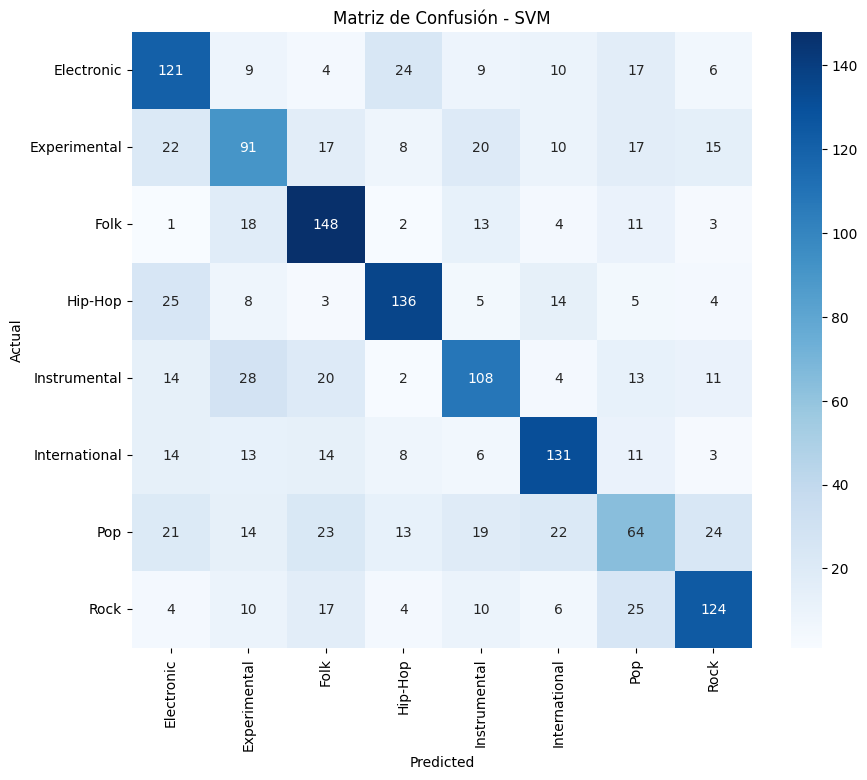

In [4]:
results = []

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred, average='macro')
    gap = train_acc - test_acc
    
    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'F1 Macro': f1,
        'Overfitting Gap': gap
    })

results_df = pd.DataFrame(results).set_index('Model')
display(results_df)

best_model_name = results_df['F1 Macro'].idxmax()
best_model = trained_models[best_model_name]
print(f"\n🏆 Mejor modelo: {best_model_name}")

y_pred_best = best_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=genres))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres)
plt.title(f"Matriz de Confusión - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 5. Guardado del modelo final

In [5]:
joblib.dump(best_model, BACKEND_DIR / 'model_final.pkl')
joblib.dump(scaler, BACKEND_DIR / 'scaler_final.pkl')

with open(BACKEND_DIR / 'genres_final.json', 'w') as f:
    json.dump(genres, f)

best_f1 = results_df.loc[best_model_name, 'F1 Macro']
best_gap = results_df.loc[best_model_name, 'Overfitting Gap']

print(f"✅ Modelo guardado: {best_model_name}")
print(f"✅ F1 Macro (Test): {best_f1:.4f}")
print(f"✅ Overfitting Gap: {best_gap:.4f}")

✅ Modelo guardado: SVM
✅ F1 Macro (Test): 0.5729
✅ Overfitting Gap: 0.3776
